In [1]:
import cv2
import numpy as np

In [2]:
img = cv2.imread("person.jpg")

height, width, channels = img.shape
mid_h, mid_w = height // 2, width // 2

def cv2_cleanup():
    cv2.waitKey()
    cv2.destroyAllWindows()

cv2.imshow("Original Photo", img)
cv2_cleanup()

In [3]:
# 1 - Passport Photo Preparation 

"""
A passport application portal accepts photographs of only 600 × 600 pixels. Write a program 
to read a passport photo, resize it to the required dimensions, and save the resized image. 
"""

passport_photo = cv2.resize(img, (600, 600))
cv2.imshow("Passport Photo", passport_photo)
cv2_cleanup()

In [4]:
# 2 - Social Media Profile Picture

"""
A social media platform displays only the center portion of a profile picture. Write a 
program to crop the center 300 × 300 pixels of an image and save it as the profile picture.
"""

# for center 300 from each side of center point 150 pixels each side
social_media_pfp = img[mid_h-150:mid_h+150, mid_w-150:mid_w+150, :]
cv2.imshow("Social Media PFP", social_media_pfp)
cv2_cleanup()

In [5]:
# 3 - CCTV Face Extraction

"""
A CCTV image contains a person standing at the center of the frame. Extract only the Region 
of Interest (ROI) containing the person's face by cropping the center of the image.
"""

# looks like middle 600 x 600 pixels
cctv_face = img[mid_h-300:mid_h+300, mid_w-300:mid_w+300, :]
cv2.imshow("CCTV Face Extraction", cctv_face)
cv2_cleanup()

In [6]:
# 4 - Medical Image Preprocessing

"""
Medical imaging systems often process grayscale images to reduce computational 
complexity. Write a program to convert a color medical image into grayscale and save the 
output. 
"""

medical_image = cv2.imread("medical.jpg")
medical_image = cv2.resize(medical_image, (500, 500))
cv2.imshow("Medical Colored", medical_image)
cv2_cleanup()

medical_gray = cv2.cvtColor(medical_image, cv2.COLOR_BGR2GRAY)
cv2.imshow("Medical Grayscale", medical_gray)
cv2_cleanup()

In [7]:
# 5 - Traffic Signal Detection

"""
Autonomous vehicles often detect traffic lights using the HSV color space. Convert a traffic 
image from BGR to HSV format. 
"""

traffic_light = cv2.imread("traffic.jpg")
traffic_light = cv2.resize(traffic_light, (400, 600))
cv2.imshow("Traffic Light BGR", traffic_light)
cv2_cleanup()

traffic_light_gray = cv2.cvtColor(traffic_light, cv2.COLOR_BGR2HSV)
cv2.imshow("Traffic Light HSV", traffic_light_gray)
cv2_cleanup()

In [8]:
# 6 - Printing Image Information

"""
Before processing an image, an engineer wants to know its dimensions, color channels, and 
data type. Write a program to display all these properties. 
"""

height, width, color_chnnels = img.shape
dimensions = (height, width)
print(f"Dimension: {dimensions}")
print(f"Height: {height}px, Width: {width}px")
print(f"Color Channels: {color_chnnels} channels")
print(f"Data Type: {img.dtype}")

Dimension: (1250, 1000)
Height: 1250px, Width: 1000px
Color Channels: 3 channels
Data Type: uint8


In [9]:
# 7 - Pixel Inspection

"""
A scientist wants to examine the color value of a specific location in a satellite image. Write a 
program to display the BGR values of pixel (150,150). 
"""

colors = ["Blue", "Green", "Red"]
pixel_150_150 = img[150, 150, :]
print(f"Pixel of (150, 150): {pixel_150_150}")
print(f", ".join( f"{colors[i]}={pixel_150_150[i]}" for i in range(3)))

Pixel of (150, 150): [192 141 149]
Blue=192, Green=141, Red=149


In [10]:
# 8 - Highlighting a Defective Area

"""
In a quality inspection system, a defective region needs to be highlighted. Draw a 100 × 100 
green square on the image by modifying pixel values. 
"""

defective_sample = cv2.imread("sample.jpg")
defective_sample = cv2.resize(defective_sample, (500, 500))

dh, dw, dc = defective_sample.shape # defective image properties
dmh, dmw = dh // 2, dw // 2 # defective image midpoints

defective_region = np.array([
    [ [0, 255, 0] for _ in range(100) ] for _ in range(100)
])
defective_sample[dmh-50:dmh+50, dmw-50:dmw+50, :]= defective_region

cv2.imshow("Defective Sample Original", defective_sample)
cv2_cleanup()

In [11]:
# 9 - Image Compression Preview

"""
A website generates thumbnails before uploading images. Resize the original image to 25%, 
50%, and 75% of its original size and compare the outputs. 
"""

thumbnail_100 = cv2.imread("sample.jpg")
thumbnail_height, thumbnail_width, thumbnail_channels = thumbnail_100.shape

cv2.imshow("Thumbnail - 100%", thumbnail_100)
cv2_cleanup()

thm_h25, thm_w25 = int(height // 4), int(width // 4) 
thm_h50, thm_w50 = int(height // 2), int(width // 2) 
thm_h75, thm_w75 = thm_h25 * 3, thm_w25 * 3 

thumbnail_25 = cv2.resize(thumbnail_100, (thm_h25, thm_w25))
thumbnail_50 = cv2.resize(thumbnail_100, (thm_h50, thm_w50))
thumbnail_75 = cv2.resize(thumbnail_100, (thm_h75, thm_w75))

cv2.imshow("Thumbnail - 25%", thumbnail_25)
cv2_cleanup()

cv2.imshow("Thumbnail - 50%", thumbnail_50)
cv2_cleanup()

cv2.imshow("Thumbnail - 75%", thumbnail_75)
cv2_cleanup()

In [15]:
# 10 - Compare Image Quality 

"""
Different resizing techniques produce different image qualities. Resize an image using 
Nearest Neighbor, Linear, and Cubic interpolation, then compare the results. 
"""

thumbnail_compressed = cv2.resize(thumbnail_100, (400, 400))
cv2.imshow("Original Image", thumbnail_compressed)
cv2_cleanup()

# Scaling all to 2000 x 2000
thumbnail_nn = cv2.resize(thumbnail_compressed, (600, 600), interpolation=cv2.INTER_NEAREST)
cv2.imshow("Nearest Neighbor", thumbnail_nn)
cv2_cleanup()

thumbnail_linear = cv2.resize(thumbnail_compressed, (600, 600), interpolation=cv2.INTER_LINEAR)
cv2.imshow("Linear Interpolation", thumbnail_linear)
cv2_cleanup()

thumbnail_cubic = cv2.resize(thumbnail_compressed, (600, 600), interpolation=cv2.INTER_CUBIC)
cv2.imshow("Cubic Interpolation", thumbnail_cubic)
cv2_cleanup()

In [18]:
# 11 - Image Dataset Preparation

"""
A machine learning model requires images of size 224 × 224 pixels. Resize an image 
accordingly and save it for model training. 
"""

animal = cv2.imread("animal.jpg")
cv2.imshow("Animal", animal)
cv2_cleanup()

animal_compressed = cv2.resize(animal, (224, 224))
cv2.imshow("ML Image", animal_compressed)
cv2_cleanup()
cv2.imwrite("compressed.jpg", animal_compressed)

True

In [16]:
# 12 - Wildlife Monitoring 

"""
A wildlife camera captures large images, but the animal appears only in the lower-right 
corner. Crop only the bottom-right region and display it. 
"""

ah, aw, _ = animal.shape
amh, amw = ah // 2, aw // 2
bottom_right_animal = animal[amh:, amh:, :]

cv2.imshow("Bottom Right Part", bottom_right_animal)
cv2_cleanup()

In [61]:
# 13 - Document Scanning

"""
A scanned document contains unnecessary borders. Crop only the useful portion of the 
document before saving it. 
"""

document = cv2.imread("document.jpg")
document = cv2.resize(document, (600, 800))
cv2.imshow("Document", document)
cv2_cleanup()

# Etimated border are all side outer 50 pixels each side 
document_without_border = document[50:-50, 50:-50, :]
cv2.imshow("Document - No Borders", document_without_border)
cv2_cleanup()

In [40]:
# 14 - Digital Photo Album

"""
Convert a color photograph into grayscale to create a black-and-white photo album. 
"""

person = cv2.imread("person.jpg")
person = cv2.resize(person, (450, 600))
cv2.imshow("Person Colored", person)
cv2_cleanup()

person_gray = cv2.cvtColor(person, cv2.COLOR_BGR2GRAY)
cv2.imshow("Person Album Style", person_gray)
cv2_cleanup()
cv2.imwrite("album.jpg", person_gray)

True

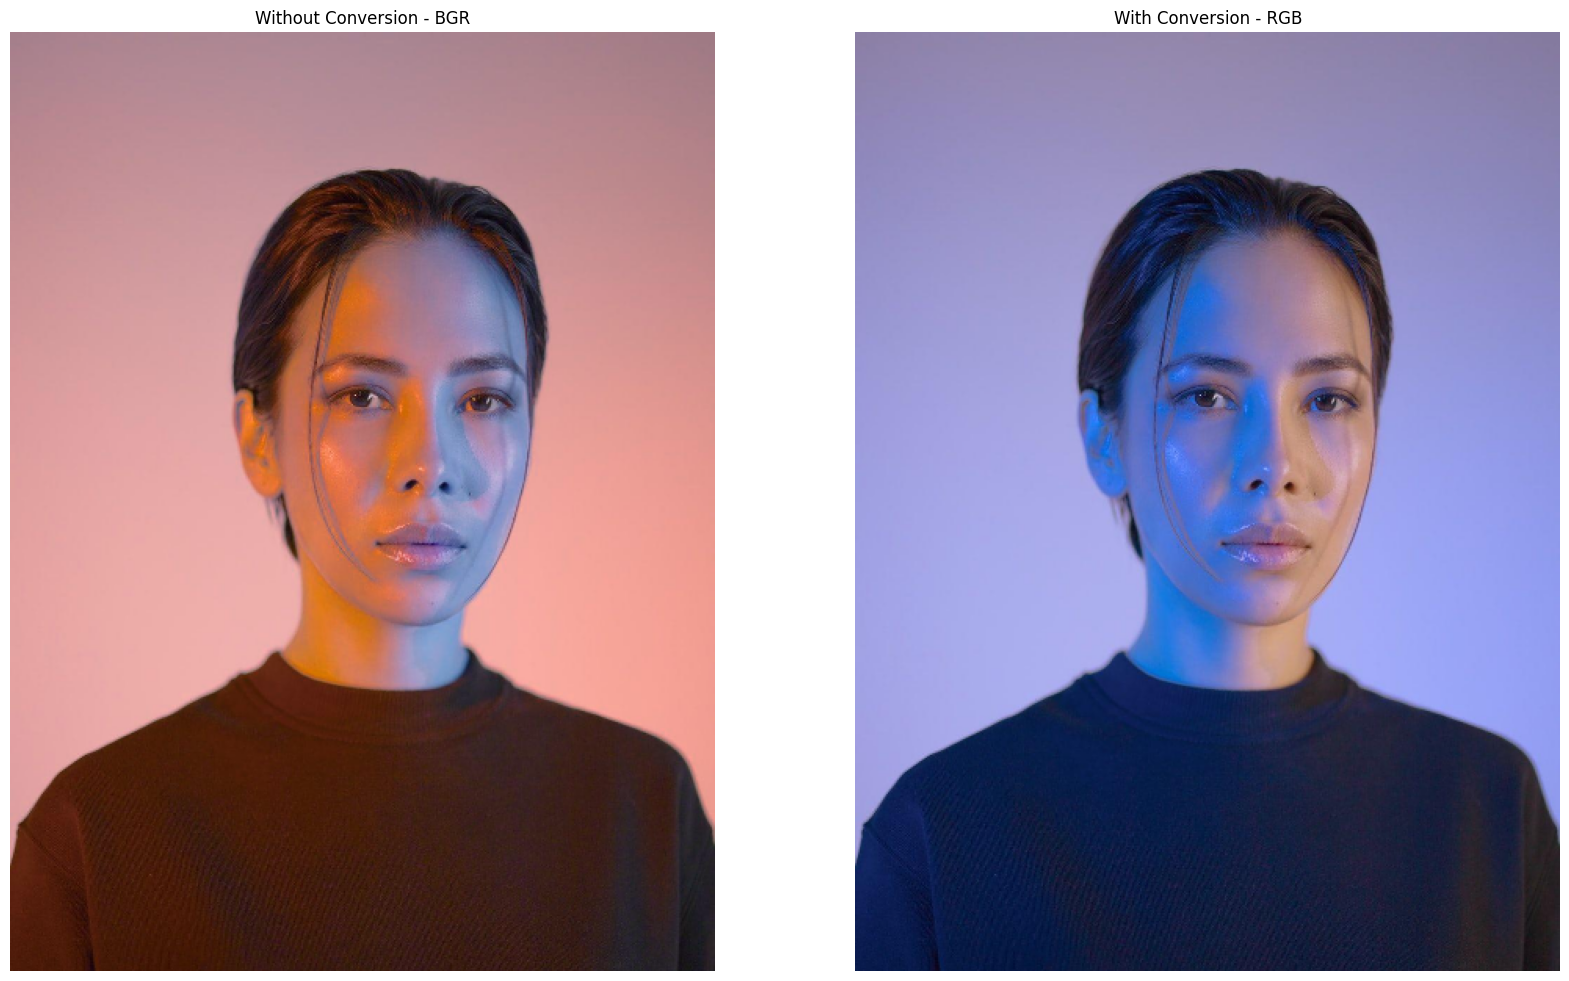

In [60]:
# 15 - RGB Image Display

"""
Matplotlib displays OpenCV images with incorrect colors because OpenCV stores images in 
BGR format. Convert the image to RGB before displaying it. 
"""

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 16))
ax[0].imshow(person)
ax[0].axis(False)
ax[0].set_title("Without Conversion - BGR")

person_rgb = cv2.cvtColor(person, cv2.COLOR_BGR2RGB)
ax[1].imshow(person_rgb)
ax[1].axis(False)
ax[1].set_title("With Conversion - RGB")

plt.show()